# Addition Technologies Pvt Ltd – Self-Serve Kiosk Sales Analysis

**Company:** Addition Technologies Pvt Ltd  
**Business:** Self-Serve Food Ordering Kiosks  
**Client Restaurants (Bangalore):**
- Veena Stores
- Rameshwaram Cafe
- BigByte
- Asha Sweets

**Period:** January 2024 – December 2024

---

## Dashboard Structure
| Dashboard | Audience | Key Metrics |
|-----------|----------|-------------|
| **Dashboard 1 – Per-Restaurant** | Each client restaurant | Food-item wise sales, category breakdown, daily/monthly trends |
| **Dashboard 2 – Company Overview** | Addition Technologies | Monthly revenue across all clients, total footfall per outlet, top performing kiosk location |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Style ──────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#F8F9FA',
    'axes.facecolor':   '#FFFFFF',
    'axes.grid':        True,
    'grid.alpha':       0.4,
    'font.family':      'sans-serif',
    'axes.spines.top':  False,
    'axes.spines.right': False,
})

RESTAURANT_COLORS = {
    'Veena Stores':     '#2E86AB',
    'Rameshwaram Cafe': '#A23B72',
    'BigByte':          '#F18F01',
    'Asha Sweets':      '#C73E1D',
}

# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('kiosk_sales_data.csv', parse_dates=['Date'])
df['Month_Period'] = pd.to_datetime(df['Month'])
print(f"Total records : {len(df):,}")
print(f"Date range    : {df['Date'].min().date()} → {df['Date'].max().date()}")
df.head(3)

Total records : 162,370
Date range    : 2024-01-01 → 2024-12-31


,Order_ID,Date,Month,Month_Name,Restaurant,Category,Food_Item,Unit_Price,Quantity,Discount_Pct,Discount_Amount,Total_Sales,Customer_ID,Month_Period
0,ORD-000001,2024-01-01,2024-01,January 2024,Veena Stores,Breakfast,Plain Idli,30,2,0,0.0,60.0,CUST-28289,2024-01-01
1,ORD-000002,2024-01-01,2024-01,January 2024,Veena Stores,Beverages,Filter Coffee,20,2,5,2.0,38.0,CUST-21395,2024-01-01
2,ORD-000003,2024-01-01,2024-01,January 2024,Veena Stores,Breakfast,Poori Bhaji,50,1,0,0.0,50.0,CUST-40495,2024-01-01


---
## Dashboard 1 – Per-Restaurant Sales (Food-Item Level)
> **Purpose:** Each client restaurant can see exactly how many units were sold and the revenue generated per food item over the year. A slicer / filter panel in Power BI lets the restaurant owner select their outlet.

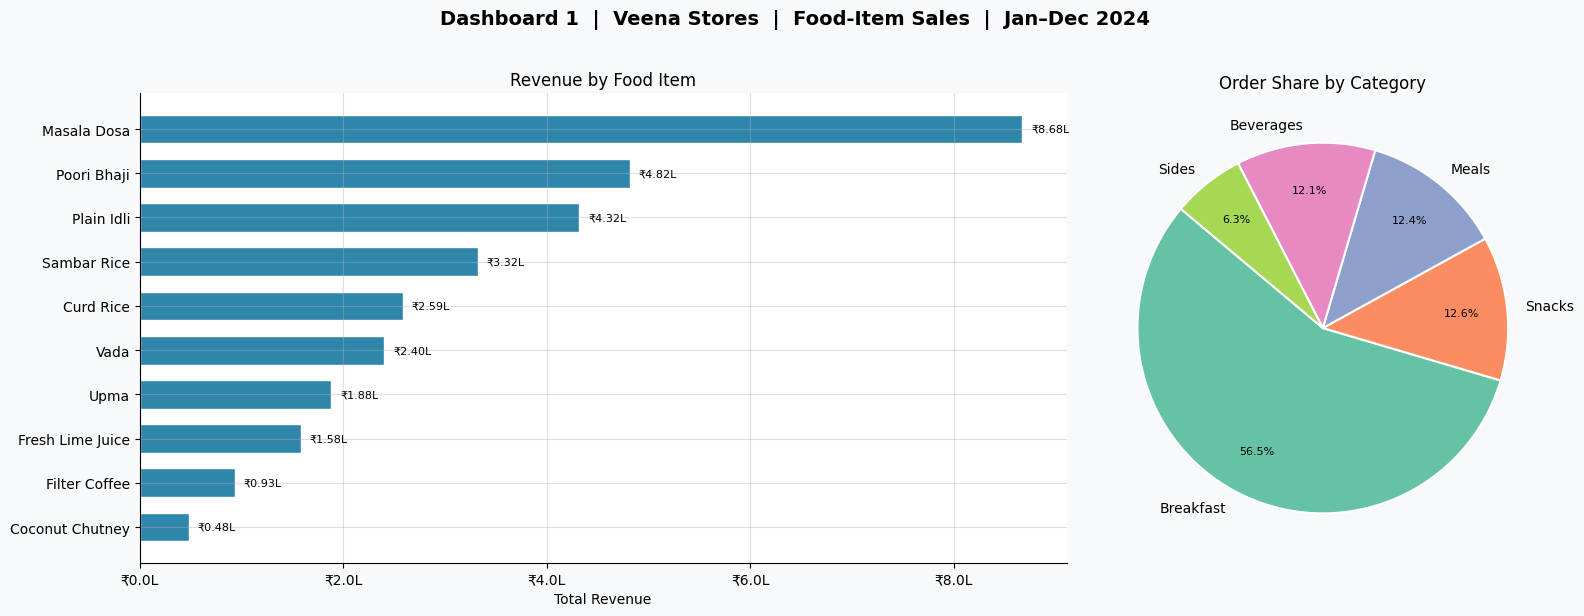

  → Veena Stores: ₹3,100,573 total revenue, 44,365 kiosk orders



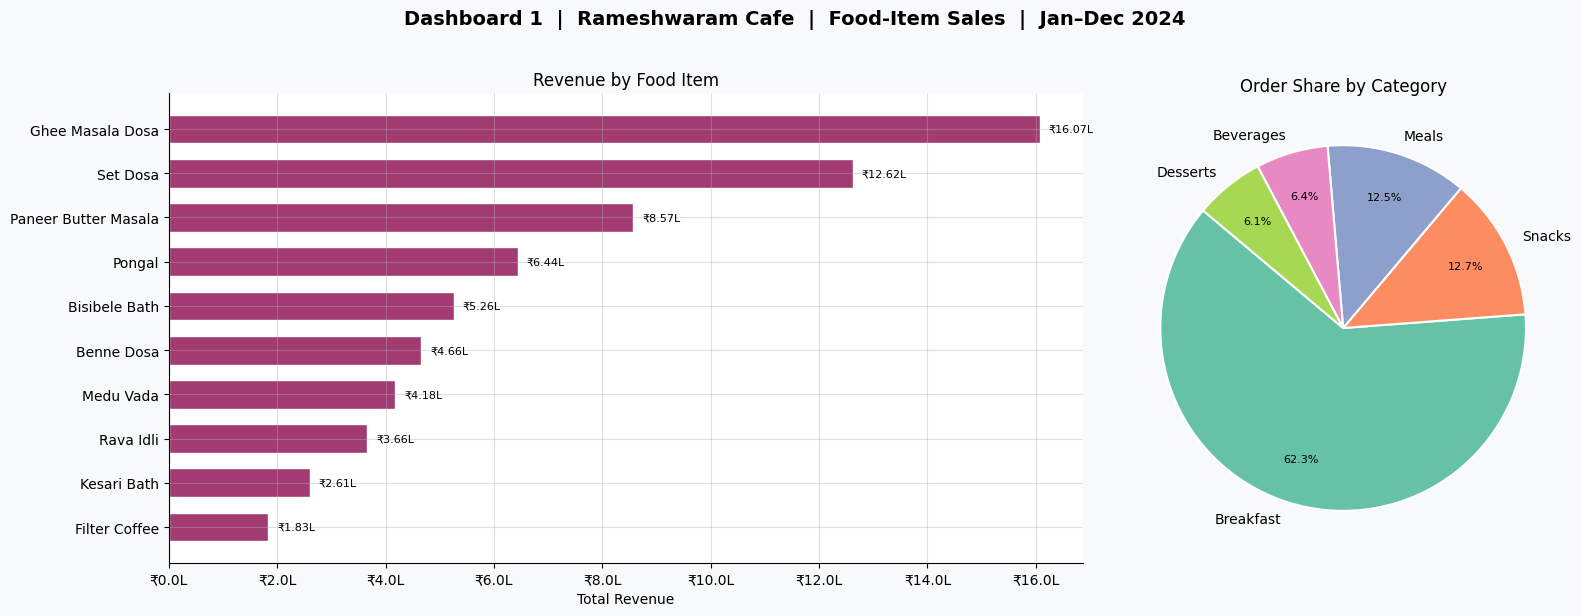

  → Rameshwaram Cafe: ₹6,590,714 total revenue, 55,768 kiosk orders



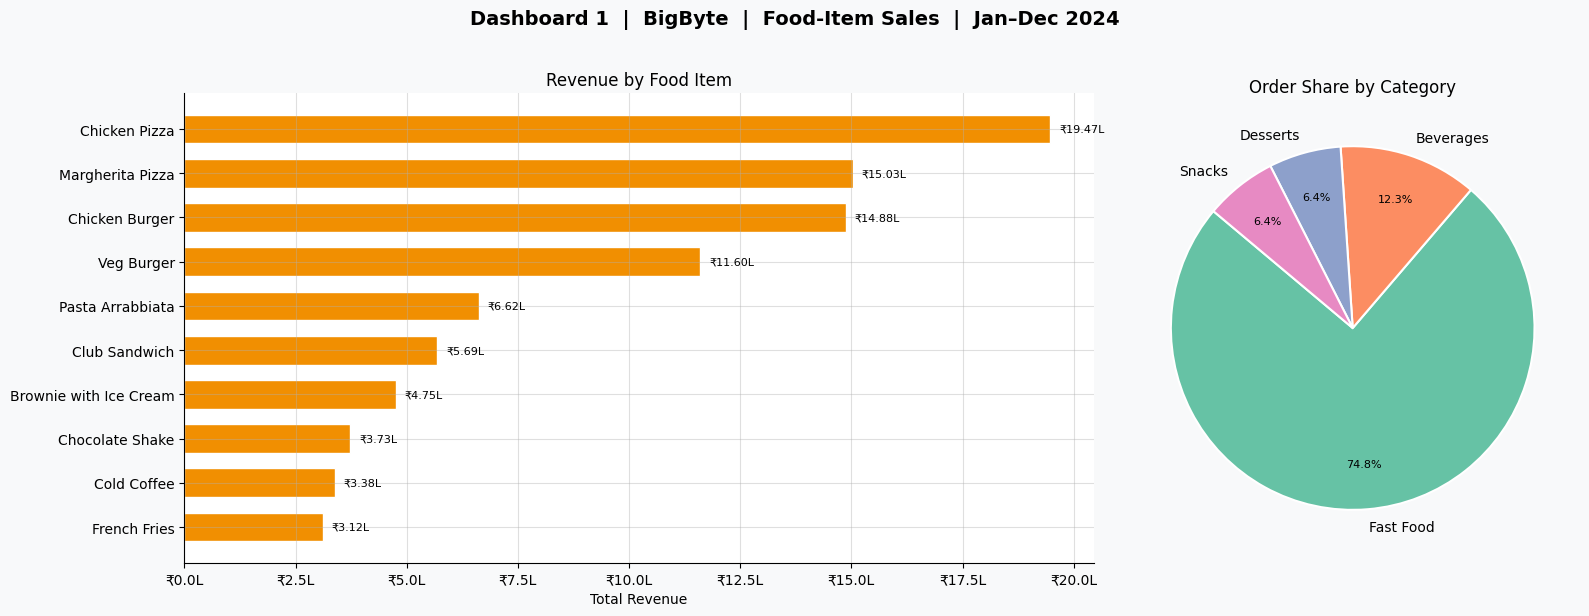

  → BigByte: ₹8,827,989 total revenue, 36,041 kiosk orders



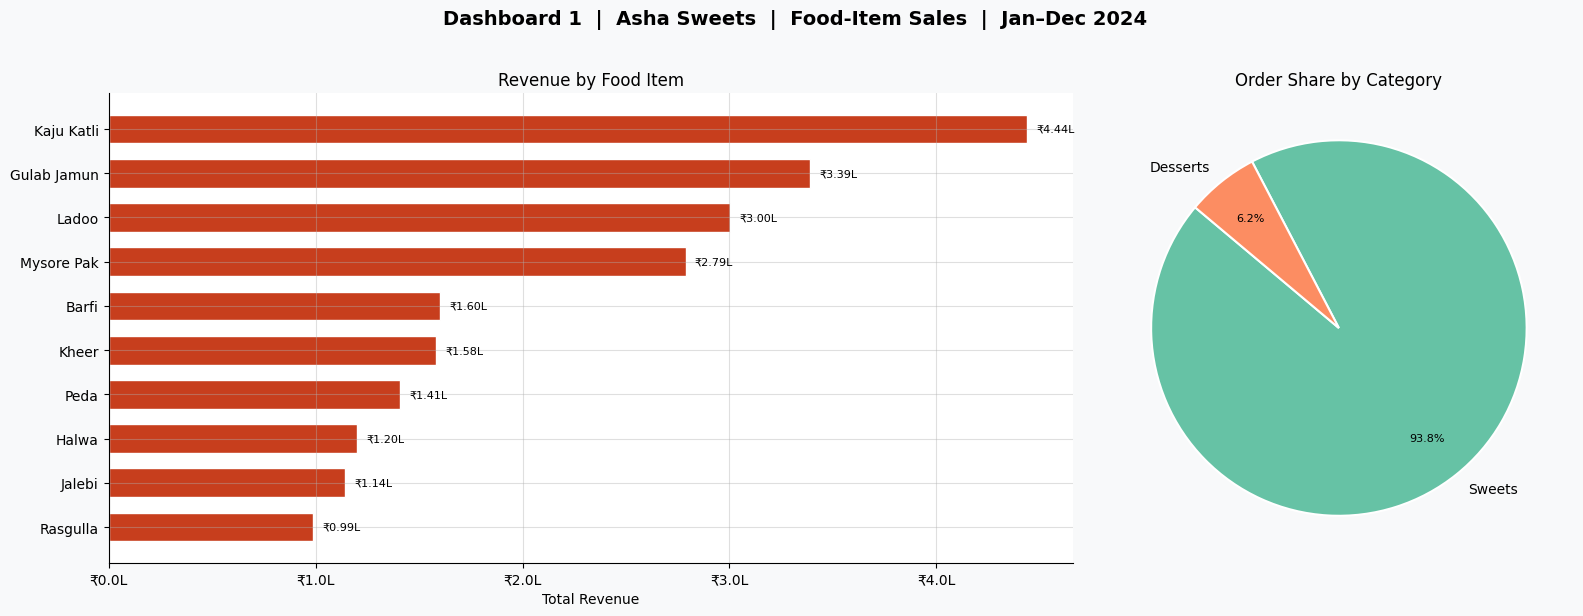

  → Asha Sweets: ₹2,154,310 total revenue, 26,196 kiosk orders



In [2]:
RESTAURANTS = list(RESTAURANT_COLORS.keys())

for restaurant in RESTAURANTS:
    rdf = df[df['Restaurant'] == restaurant]

    item_sales = (
        rdf.groupby('Food_Item', as_index=False)
           .agg(Total_Revenue=('Total_Sales', 'sum'),
                Total_Orders=('Order_ID', 'count'),
                Total_Qty=('Quantity', 'sum'))
           .sort_values('Total_Revenue', ascending=True)
    )

    color = RESTAURANT_COLORS[restaurant]
    fig, axes = plt.subplots(1, 2, figsize=(16, 6),
                             gridspec_kw={'width_ratios': [2, 1]})
    fig.suptitle(f'Dashboard 1  |  {restaurant}  |  Food-Item Sales  |  Jan–Dec 2024',
                 fontsize=14, fontweight='bold', y=1.02)

    # ── Left: Revenue by Food Item (horizontal bar) ────────────────────────
    ax = axes[0]
    bars = ax.barh(item_sales['Food_Item'], item_sales['Total_Revenue'],
                   color=color, edgecolor='white', height=0.65)
    for bar, rev in zip(bars, item_sales['Total_Revenue']):
        ax.text(bar.get_width() + item_sales['Total_Revenue'].max() * 0.01,
                bar.get_y() + bar.get_height() / 2,
                f'₹{rev/1_00_000:.2f}L', va='center', fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1_00_000:.1f}L'))
    ax.set_xlabel('Total Revenue')
    ax.set_title('Revenue by Food Item')

    # ── Right: Orders by Category (pie) ────────────────────────────────────
    ax2 = axes[1]
    cat_orders = rdf.groupby('Category')['Order_ID'].count().sort_values(ascending=False)
    wedge_colors = sns.color_palette('Set2', len(cat_orders))
    wedges, texts, autotexts = ax2.pie(
        cat_orders, labels=cat_orders.index, autopct='%1.1f%%',
        colors=wedge_colors, startangle=140, pctdistance=0.75,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
    )
    for at in autotexts:
        at.set_fontsize(8)
    ax2.set_title('Order Share by Category')

    plt.tight_layout()
    plt.savefig(f'/tmp/dashboard1_{restaurant.replace(" ","_")}.png', dpi=120, bbox_inches='tight')
    plt.show()
    print(f"  → {restaurant}: ₹{rdf['Total_Sales'].sum():,.0f} total revenue, {len(rdf):,} kiosk orders")
    print()

---
## Dashboard 1 – Monthly Sales Trend per Restaurant

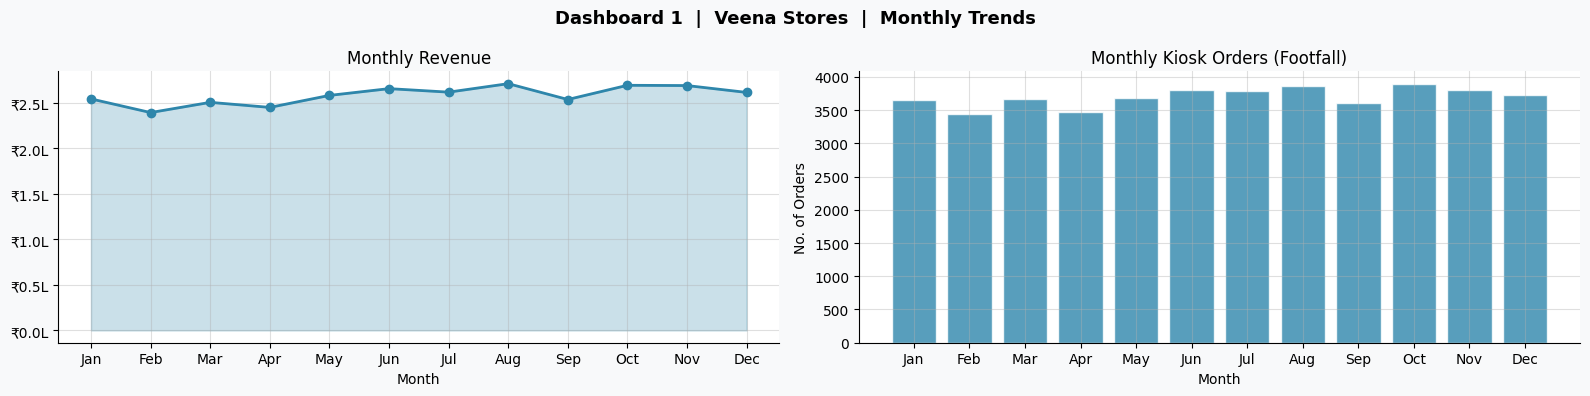

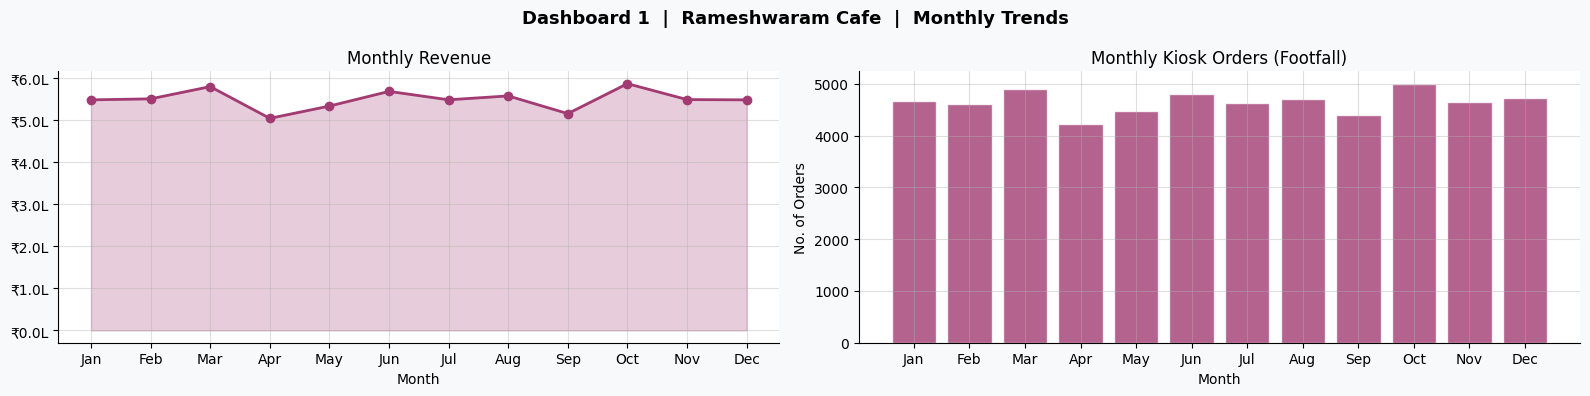

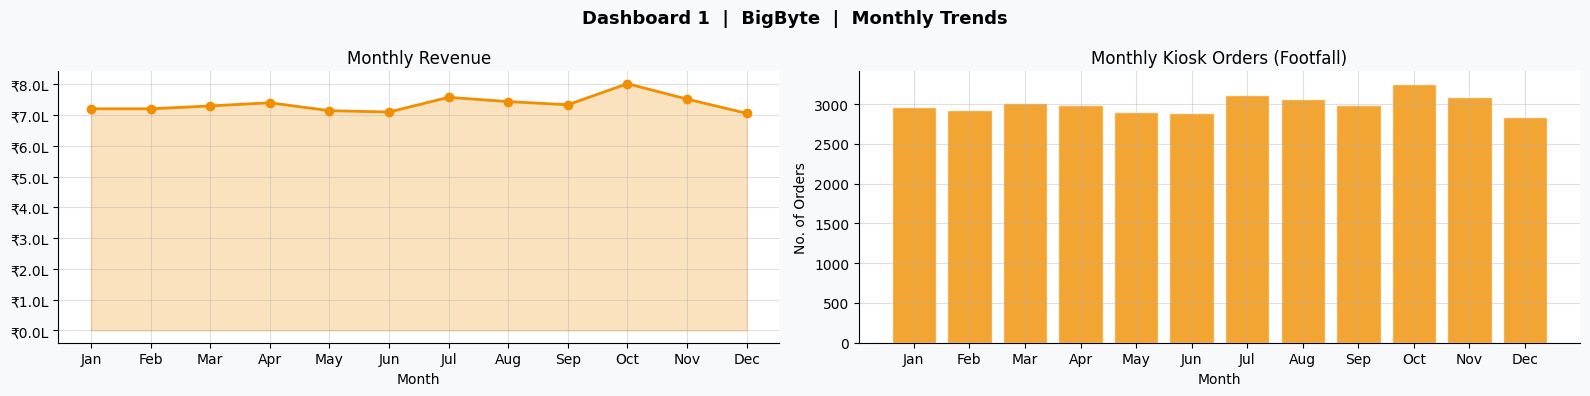

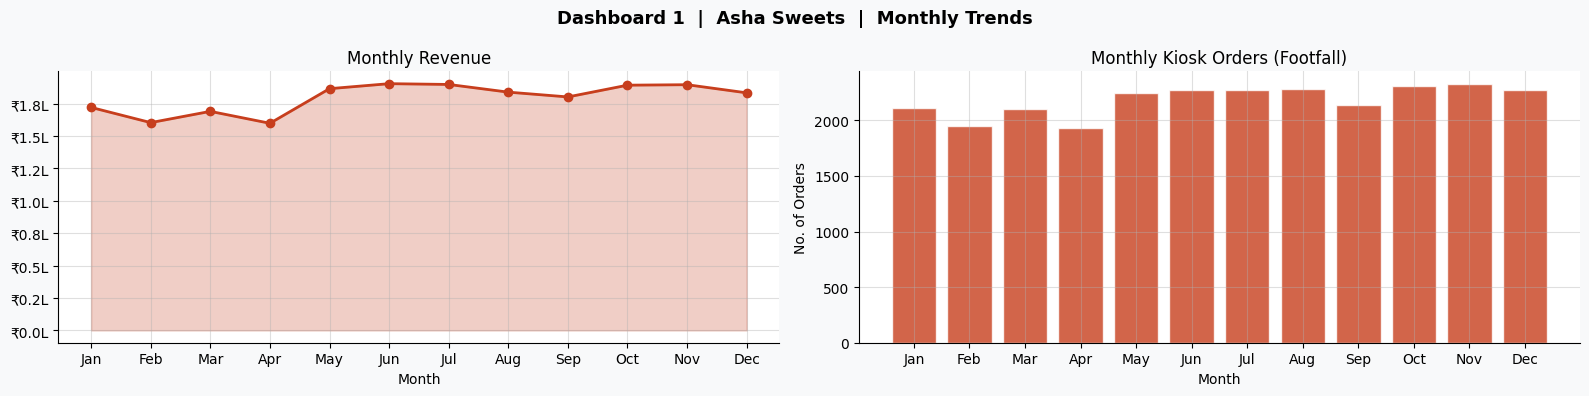

In [3]:
for restaurant in RESTAURANTS:
    rdf = df[df['Restaurant'] == restaurant]
    monthly = (
        rdf.groupby('Month_Period')
           .agg(Revenue=('Total_Sales', 'sum'),
                Orders=('Order_ID', 'count'),
                Footfall=('Customer_ID', 'nunique'))
           .reset_index()
    )

    color = RESTAURANT_COLORS[restaurant]
    fig, axes = plt.subplots(1, 2, figsize=(16, 4))
    fig.suptitle(f'Dashboard 1  |  {restaurant}  |  Monthly Trends',
                 fontsize=13, fontweight='bold')

    months_fmt = [d.strftime('%b') for d in monthly['Month_Period']]

    # Revenue trend
    axes[0].fill_between(months_fmt, monthly['Revenue'], alpha=0.25, color=color)
    axes[0].plot(months_fmt, monthly['Revenue'], marker='o', color=color, linewidth=2)
    axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1_00_000:.1f}L'))
    axes[0].set_title('Monthly Revenue')
    axes[0].set_xlabel('Month')

    # Orders trend
    axes[1].bar(months_fmt, monthly['Orders'], color=color, alpha=0.8, edgecolor='white')
    axes[1].set_title('Monthly Kiosk Orders (Footfall)')
    axes[1].set_xlabel('Month')
    axes[1].set_ylabel('No. of Orders')

    plt.tight_layout()
    plt.show()

---
## Dashboard 1 – Top 5 Food Items per Restaurant (Quick KPI Table)

In [4]:
print(f"{'Restaurant':<22} {'Food Item':<30} {'Orders':>8} {'Qty Sold':>10} {'Revenue (₹)':>14}")
print("-" * 90)
for restaurant in RESTAURANTS:
    rdf = df[df['Restaurant'] == restaurant]
    top5 = (
        rdf.groupby('Food_Item')
           .agg(Orders=('Order_ID', 'count'),
                Qty=('Quantity', 'sum'),
                Revenue=('Total_Sales', 'sum'))
           .sort_values('Revenue', ascending=False)
           .head(5)
    )
    for i, (item, row) in enumerate(top5.iterrows()):
        rest_label = restaurant if i == 0 else ''
        print(f"{rest_label:<22} {item:<30} {row['Orders']:>8,} {row['Qty']:>10,} {row['Revenue']:>14,.0f}")
    print()

Restaurant             Food Item                        Orders   Qty Sold    Revenue (₹)
------------------------------------------------------------------------------------------
Veena Stores           Masala Dosa                     8,399.0   14,755.0        867,549
                       Poori Bhaji                     5,620.0    9,822.0        481,502
                       Plain Idli                      8,309.0   14,697.0        432,140
                       Sambar Rice                     2,783.0    4,845.0        332,066
                       Curd Rice                       2,733.0    4,801.0        258,868

Rameshwaram Cafe       Ghee Masala Dosa               10,483.0   18,219.0      1,606,860
                       Set Dosa                       10,483.0   18,404.0      1,262,286
                       Paneer Butter Masala            3,552.0    6,255.0        857,024
                       Pongal                          6,809.0   11,946.0        643,750
                  

---
## Dashboard 2 – Company Overview (Addition Technologies Pvt Ltd)

> **Purpose:** Addition Technologies management can see total monthly sales across all 4 client restaurants and measure customer footfall (kiosk usage) to determine which outlet has the highest self-serve kiosk adoption.

In [5]:
# ── KPI Summary ────────────────────────────────────────────────────────────
total_revenue   = df['Total_Sales'].sum()
total_orders    = len(df)
total_footfall  = df['Customer_ID'].nunique()
avg_order_value = df['Total_Sales'].mean()

print("╔══════════════════════════════════════════════════════════════╗")
print("║      ADDITION TECHNOLOGIES PVT LTD  –  COMPANY DASHBOARD    ║")
print("╠══════════════════════════════════════════════════════════════╣")
print(f"║  Total Kiosk Revenue  : ₹ {total_revenue:>12,.0f}                    ║")
print(f"║  Total Kiosk Orders   : {total_orders:>15,}                    ║")
print(f"║  Unique Customer IDs  : {total_footfall:>15,}                    ║")
print(f"║  Avg Order Value      : ₹ {avg_order_value:>12.2f}                    ║")
print("╚══════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════╗
║      ADDITION TECHNOLOGIES PVT LTD  –  COMPANY DASHBOARD    ║
╠══════════════════════════════════════════════════════════════╣
║  Total Kiosk Revenue  : ₹   20,673,586                    ║
║  Total Kiosk Orders   :         162,370                    ║
║  Unique Customer IDs  :          75,326                    ║
║  Avg Order Value      : ₹       127.32                    ║
╚══════════════════════════════════════════════════════════════╝


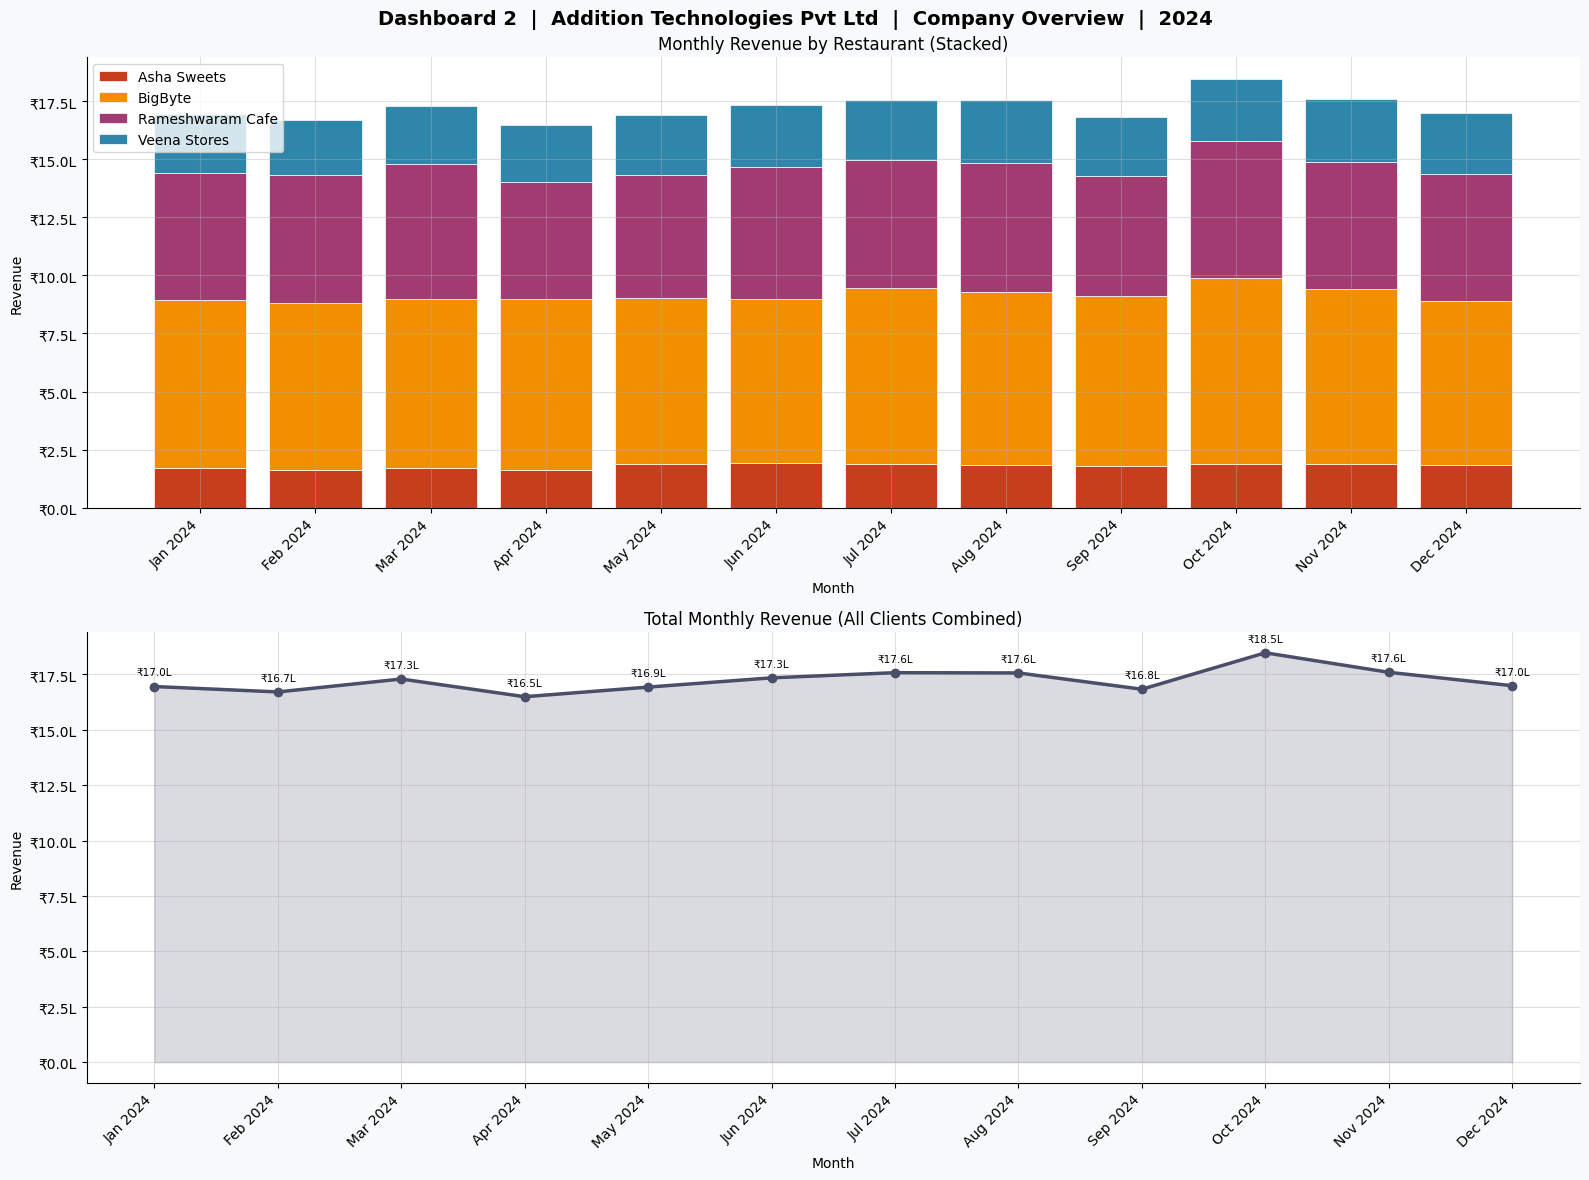

In [6]:
# ── Monthly Revenue – All Clients Stacked ─────────────────────────────────
monthly_rest = (
    df.groupby(['Month_Period', 'Restaurant'])['Total_Sales']
      .sum()
      .unstack('Restaurant')
      .fillna(0)
)

months_fmt = [d.strftime('%b %Y') for d in monthly_rest.index]
colors = [RESTAURANT_COLORS[r] for r in monthly_rest.columns]

fig, axes = plt.subplots(2, 1, figsize=(16, 12))
fig.suptitle('Dashboard 2  |  Addition Technologies Pvt Ltd  |  Company Overview  |  2024',
             fontsize=14, fontweight='bold')

# Stacked bar – monthly revenue
bottom = np.zeros(len(monthly_rest))
for col, color in zip(monthly_rest.columns, colors):
    vals = monthly_rest[col].values
    axes[0].bar(months_fmt, vals, bottom=bottom, label=col, color=color,
                edgecolor='white', linewidth=0.5)
    bottom += vals
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1_00_000:.1f}L'))
axes[0].set_title('Monthly Revenue by Restaurant (Stacked)')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue')
axes[0].legend(loc='upper left', framealpha=0.8)
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')

# Line chart – month-over-month total
monthly_total = monthly_rest.sum(axis=1)
axes[1].fill_between(months_fmt, monthly_total, alpha=0.2, color='#4A4E69')
axes[1].plot(months_fmt, monthly_total, marker='o', color='#4A4E69', linewidth=2.5, label='Total')
for x, y in zip(months_fmt, monthly_total):
    axes[1].annotate(f'₹{y/1_00_000:.1f}L', (x, y),
                     textcoords='offset points', xytext=(0, 8),
                     ha='center', fontsize=7.5)
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1_00_000:.1f}L'))
axes[1].set_title('Total Monthly Revenue (All Clients Combined)')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Revenue')
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.savefig('/tmp/dashboard2_monthly_revenue.png', dpi=120, bbox_inches='tight')
plt.show()

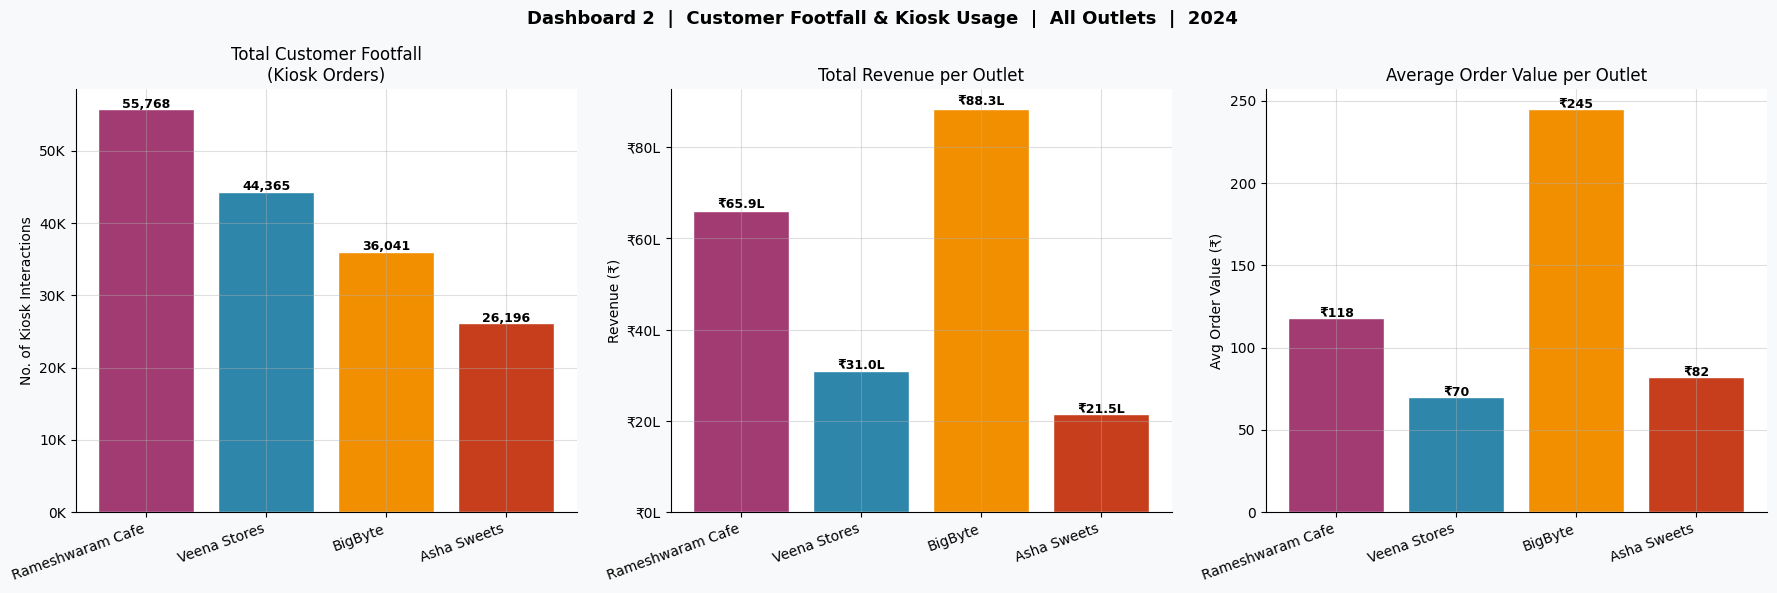


Footfall Summary:
      Restaurant  Total_Footfall  Total_Revenue  Avg_Order_Value
Rameshwaram Cafe           55768     6590714.25       118.180933
    Veena Stores           44365     3100573.00        69.887817
         BigByte           36041     8827988.60       244.942943
     Asha Sweets           26196     2154309.75        82.238118


In [7]:
# ── Footfall Dashboard ─────────────────────────────────────────────────────
# Footfall = number of kiosk orders placed (each order = 1 kiosk interaction)
footfall_by_rest = (
    df.groupby('Restaurant')
      .agg(Total_Footfall=('Order_ID', 'count'),
           Total_Revenue=('Total_Sales', 'sum'),
           Avg_Order_Value=('Total_Sales', 'mean'))
      .sort_values('Total_Footfall', ascending=False)
      .reset_index()
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Dashboard 2  |  Customer Footfall & Kiosk Usage  |  All Outlets  |  2024',
             fontsize=13, fontweight='bold')

bar_colors = [RESTAURANT_COLORS[r] for r in footfall_by_rest['Restaurant']]

# Footfall bar
bars = axes[0].bar(footfall_by_rest['Restaurant'], footfall_by_rest['Total_Footfall'],
                   color=bar_colors, edgecolor='white')
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
                 f"{int(bar.get_height()):,}", ha='center', fontsize=9, fontweight='bold')
axes[0].set_title('Total Customer Footfall\n(Kiosk Orders)')
axes[0].set_ylabel('No. of Kiosk Interactions')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Revenue bar
bars2 = axes[1].bar(footfall_by_rest['Restaurant'], footfall_by_rest['Total_Revenue'],
                    color=bar_colors, edgecolor='white')
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() * 1.01,
                 f"₹{bar.get_height()/1_00_000:.1f}L", ha='center', fontsize=9, fontweight='bold')
axes[1].set_title('Total Revenue per Outlet')
axes[1].set_ylabel('Revenue (₹)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'₹{x/1_00_000:.0f}L'))
plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=20, ha='right')

# Avg order value bar
bars3 = axes[2].bar(footfall_by_rest['Restaurant'], footfall_by_rest['Avg_Order_Value'],
                    color=bar_colors, edgecolor='white')
for bar in bars3:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f"₹{bar.get_height():.0f}", ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Average Order Value per Outlet')
axes[2].set_ylabel('Avg Order Value (₹)')
plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=20, ha='right')

plt.tight_layout()
plt.savefig('/tmp/dashboard2_footfall.png', dpi=120, bbox_inches='tight')
plt.show()

print("\nFootfall Summary:")
print(footfall_by_rest.to_string(index=False))

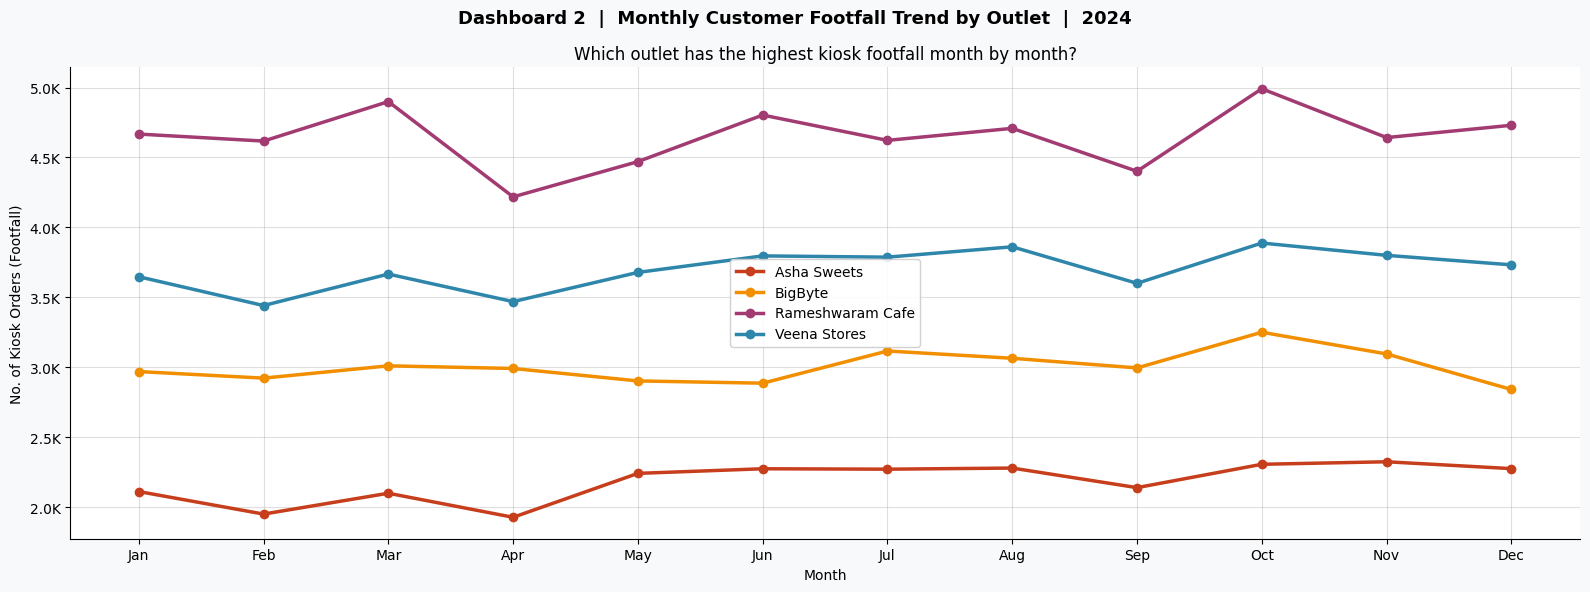

In [8]:
# ── Monthly Footfall Trend per Restaurant ─────────────────────────────────
monthly_footfall = (
    df.groupby(['Month_Period', 'Restaurant'])['Order_ID']
      .count()
      .unstack('Restaurant')
      .fillna(0)
)

months_fmt = [d.strftime('%b') for d in monthly_footfall.index]

fig, ax = plt.subplots(figsize=(16, 6))
fig.suptitle('Dashboard 2  |  Monthly Customer Footfall Trend by Outlet  |  2024',
             fontsize=13, fontweight='bold')

for restaurant in monthly_footfall.columns:
    color = RESTAURANT_COLORS[restaurant]
    ax.plot(months_fmt, monthly_footfall[restaurant],
            marker='o', linewidth=2.5, label=restaurant, color=color)

ax.set_xlabel('Month')
ax.set_ylabel('No. of Kiosk Orders (Footfall)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.1f}K'))
ax.legend(framealpha=0.9)
ax.set_title('Which outlet has the highest kiosk footfall month by month?')

plt.tight_layout()
plt.savefig('/tmp/dashboard2_footfall_trend.png', dpi=120, bbox_inches='tight')
plt.show()

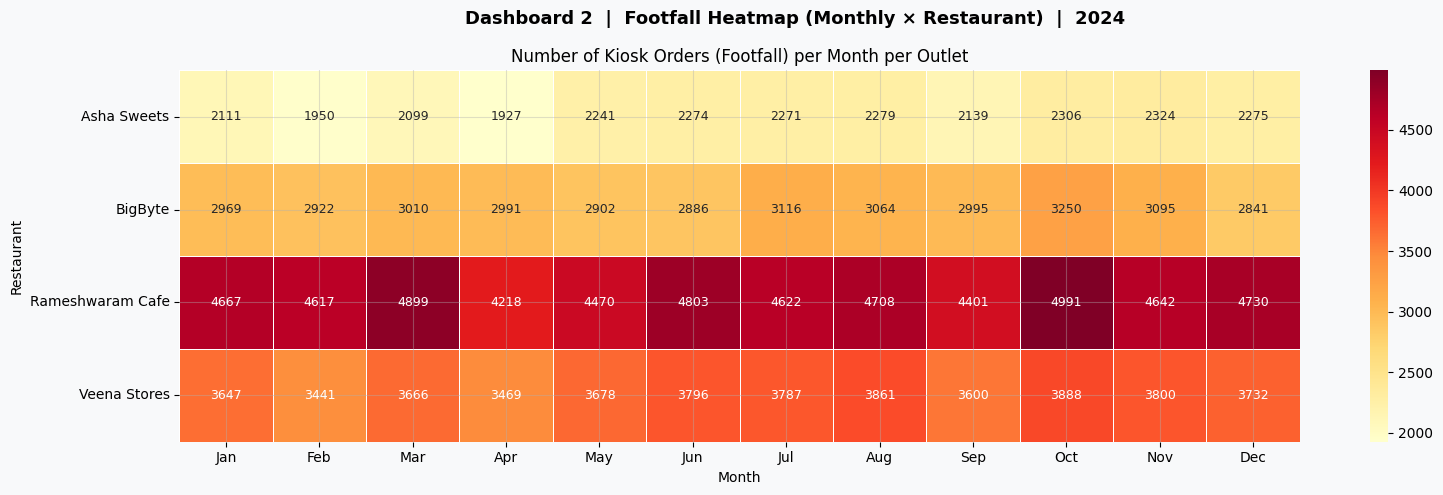

In [9]:
# ── Heatmap: Monthly footfall by restaurant ────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 5))
fig.suptitle('Dashboard 2  |  Footfall Heatmap (Monthly × Restaurant)  |  2024',
             fontsize=13, fontweight='bold')

heatmap_data = monthly_footfall.T.copy()
heatmap_data.columns = [d.strftime('%b') for d in monthly_footfall.index]

sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd',
            linewidths=0.5, ax=ax,
            annot_kws={'size': 9})
ax.set_title('Number of Kiosk Orders (Footfall) per Month per Outlet')
ax.set_xlabel('Month')
ax.set_ylabel('Restaurant')

plt.tight_layout()
plt.savefig('/tmp/dashboard2_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

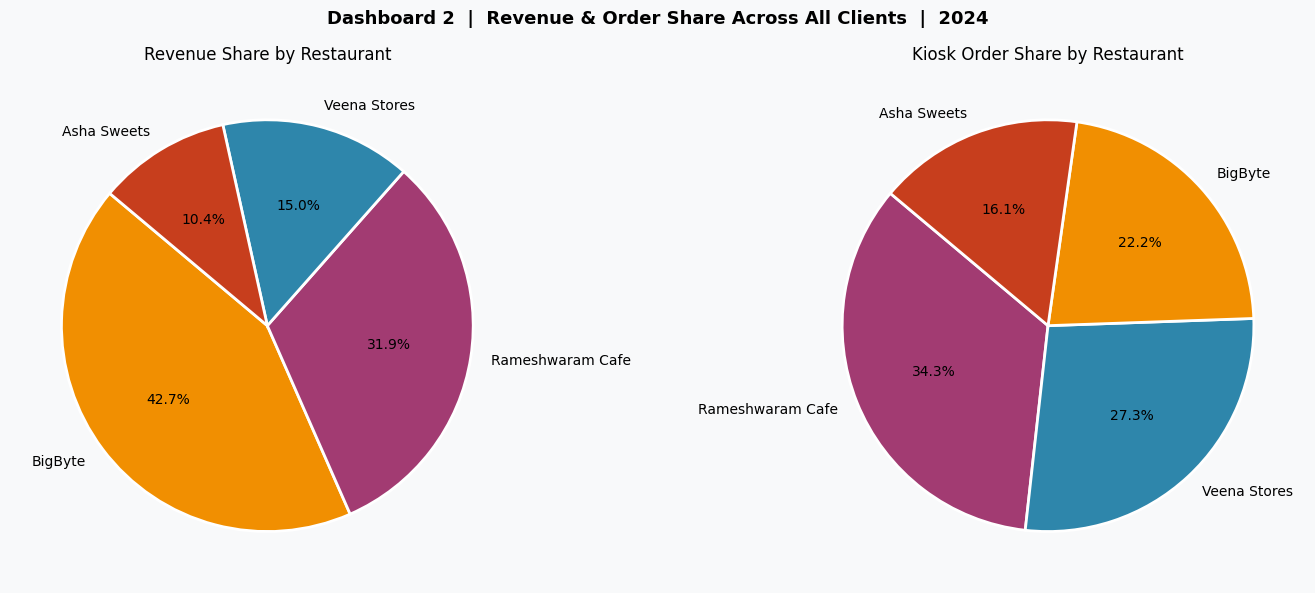

In [10]:
# ── Revenue share pie ─────────────────────────────────────────────────────
rest_rev = df.groupby('Restaurant')['Total_Sales'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Dashboard 2  |  Revenue & Order Share Across All Clients  |  2024',
             fontsize=13, fontweight='bold')

pie_colors = [RESTAURANT_COLORS[r] for r in rest_rev.index]
wedges, texts, autotexts = axes[0].pie(
    rest_rev, labels=rest_rev.index, autopct='%1.1f%%',
    colors=pie_colors, startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontsize(10)
axes[0].set_title('Revenue Share by Restaurant')

rest_orders = df.groupby('Restaurant')['Order_ID'].count().sort_values(ascending=False)
pie_colors2 = [RESTAURANT_COLORS[r] for r in rest_orders.index]
wedges2, texts2, autotexts2 = axes[1].pie(
    rest_orders, labels=rest_orders.index, autopct='%1.1f%%',
    colors=pie_colors2, startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts2:
    at.set_fontsize(10)
axes[1].set_title('Kiosk Order Share by Restaurant')

plt.tight_layout()
plt.savefig('/tmp/dashboard2_share.png', dpi=120, bbox_inches='tight')
plt.show()

---
## Key Insights Summary

In [11]:
print("=" * 65)
print("  ADDITION TECHNOLOGIES PVT LTD – KEY INSIGHTS  (2024)")
print("=" * 65)

# Highest footfall outlet
top_footfall = footfall_by_rest.iloc[0]
print(f"\n🏆 Highest Footfall Outlet : {top_footfall['Restaurant']}")
print(f"   Total Kiosk Orders       : {top_footfall['Total_Footfall']:,}")

# Highest revenue outlet
top_rev = footfall_by_rest.sort_values('Total_Revenue', ascending=False).iloc[0]
print(f"\n💰 Highest Revenue Outlet  : {top_rev['Restaurant']}")
print(f"   Total Revenue            : ₹{top_rev['Total_Revenue']:,.0f}")

# Best month overall
monthly_total = df.groupby('Month')['Total_Sales'].sum()
best_month = monthly_total.idxmax()
print(f"\n📅 Best Revenue Month      : {best_month}")
print(f"   Revenue                  : ₹{monthly_total[best_month]:,.0f}")

# Top selling item overall
top_item = df.groupby('Food_Item')['Total_Sales'].sum().idxmax()
top_item_rev = df.groupby('Food_Item')['Total_Sales'].sum().max()
print(f"\n🍽️  Top Selling Item         : {top_item}")
print(f"   Revenue                  : ₹{top_item_rev:,.0f}")

print("\n" + "-" * 65)
print("Per-Restaurant Top Item:")
for rest in RESTAURANTS:
    rdf = df[df['Restaurant'] == rest]
    best = rdf.groupby('Food_Item')['Total_Sales'].sum().idxmax()
    best_rev = rdf.groupby('Food_Item')['Total_Sales'].sum().max()
    orders = rdf.groupby('Food_Item')['Order_ID'].count()[best]
    print(f"  {rest:<22} → {best:<30} ₹{best_rev:>10,.0f}  ({orders:,} orders)")

  ADDITION TECHNOLOGIES PVT LTD – KEY INSIGHTS  (2024)

🏆 Highest Footfall Outlet : Rameshwaram Cafe
   Total Kiosk Orders       : 55,768

💰 Highest Revenue Outlet  : BigByte
   Total Revenue            : ₹8,827,989

📅 Best Revenue Month      : 2024-10
   Revenue                  : ₹1,847,359

🍽️  Top Selling Item         : Chicken Pizza
   Revenue                  : ₹1,947,479

-----------------------------------------------------------------
Per-Restaurant Top Item:
  Veena Stores           → Masala Dosa                    ₹   867,549  (8,399 orders)
  Rameshwaram Cafe       → Ghee Masala Dosa               ₹ 1,606,860  (10,483 orders)
  BigByte                → Chicken Pizza                  ₹ 1,947,479  (4,502 orders)
  Asha Sweets            → Kaju Katli                     ₹   443,800  (3,191 orders)


---
## Power BI Dashboard Setup Guide

### Data Source
Import **`kiosk_sales_data.csv`** into Power BI Desktop.  
All required columns are already present — no additional transformation is needed.

### Dashboard 1 – Per-Restaurant Client Dashboard

| Visual | Type | Fields |
|--------|------|--------|
| Food Item Revenue | Horizontal Bar Chart | Axis: `Food_Item` / Value: `Sum(Total_Sales)` |
| Food Item Orders | Column Chart | Axis: `Food_Item` / Value: `Count(Order_ID)` |
| Category Split | Donut Chart | Legend: `Category` / Value: `Sum(Total_Sales)` |
| Monthly Revenue Trend | Line Chart | X-axis: `Month` / Y-axis: `Sum(Total_Sales)` |
| KPI Cards | Card | `Sum(Total_Sales)`, `Count(Order_ID)`, `Average(Total_Sales)` |
| **Restaurant Slicer** | Slicer | Field: `Restaurant` |

> **Tip:** Add a **Slicer** on `Restaurant` so each client can filter to see only their outlet.

### Dashboard 2 – Company Overview Dashboard

| Visual | Type | Fields |
|--------|------|--------|
| Monthly Revenue (all clients) | Stacked Bar / Clustered Bar | X-axis: `Month` / Y-axis: `Sum(Total_Sales)` / Legend: `Restaurant` |
| Total Footfall by Outlet | Bar Chart | Axis: `Restaurant` / Value: `Count(Order_ID)` |
| Revenue Share | Pie / Donut | Legend: `Restaurant` / Value: `Sum(Total_Sales)` |
| Monthly Footfall Trend | Multi-line Chart | X-axis: `Month` / Y-axis: `Count(Order_ID)` / Legend: `Restaurant` |
| Footfall Heatmap | Matrix | Rows: `Restaurant` / Columns: `Month_Name` / Values: `Count(Order_ID)` |
| KPI Cards | Card | Total Revenue, Total Orders, Avg Order Value |

### Recommended DAX Measures
```dax
Total Revenue = SUM(kiosk_sales_data[Total_Sales])
Total Orders  = COUNTROWS(kiosk_sales_data)
Avg Order Value = AVERAGE(kiosk_sales_data[Total_Sales])
Total Footfall = COUNTROWS(kiosk_sales_data)
MoM Revenue Growth % =
    VAR current = [Total Revenue]
    VAR previous = CALCULATE([Total Revenue], DATEADD(kiosk_sales_data[Date], -1, MONTH))
    RETURN DIVIDE(current - previous, previous, 0) * 100
```